In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import linregress

plt.style.use("ggplot")

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
# Load datasets

nav_history = pd.read_csv("data/processed/02_nav_history_cleaned.csv")
performance = pd.read_csv("data/processed/07_scheme_performance_cleaned.csv")
benchmark = pd.read_csv("data/raw/10_benchmark_indices.csv")

print("Datasets Loaded Successfully!")

Datasets Loaded Successfully!


In [3]:
print("NAV History")
print(nav_history.columns)

print("\nPerformance")
print(performance.columns)

print("\nBenchmark")
print(benchmark.columns)

NAV History
Index(['amfi_code', 'date', 'nav'], dtype='str')

Performance
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')

Benchmark
Index(['date', 'index_name', 'close_value'], dtype='str')


In [4]:
# Task 1 - Compute Daily Returns

# Convert date column to datetime
nav_history["date"] = pd.to_datetime(nav_history["date"])

# Sort by fund and date
nav_history = nav_history.sort_values(["amfi_code", "date"])

# Calculate daily return
nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"].pct_change()
)

print("Daily Returns Calculated Successfully!")

# Show first 10 rows
nav_history.head(10)

Daily Returns Calculated Successfully!


,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


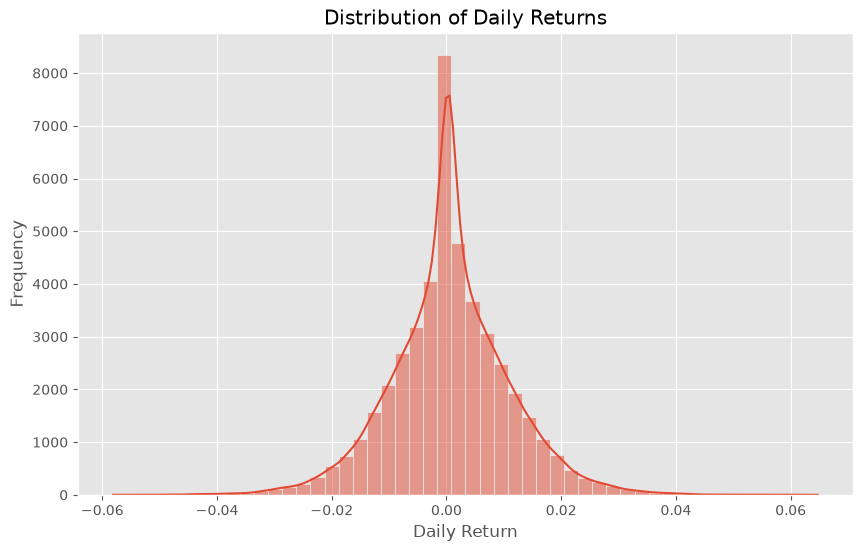

Distribution looks good!


In [5]:
# Check distribution of Daily Returns

plt.figure(figsize=(10,6))

sns.histplot(
    nav_history["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.savefig(
    "charts/Daily_Return_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Distribution looks good!")

In [6]:
# Task 2 - CAGR Comparison Table

cagr_table = performance[[
    "amfi_code",
    "scheme_name",
    "return_1yr_pct",
    "return_3yr_pct",
    "return_5yr_pct"
]]

print(cagr_table.head())

# Save CSV
cagr_table.to_csv(
    "reports/cagr_comparison.csv",
    index=False
)

print("CAGR comparison table saved successfully!")

   amfi_code                                   scheme_name  return_1yr_pct  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth           12.42   
1     119552      SBI Bluechip Fund - Direct Plan - Growth           15.25   
2     119598    SBI Small Cap Fund - Regular Plan - Growth           24.56   
3     119599     SBI Small Cap Fund - Direct Plan - Growth           20.59   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth            5.34   

   return_3yr_pct  return_5yr_pct  
0           12.36           14.45  
1           11.30           14.23  
2           23.39           20.67  
3           23.14           21.82  
4            6.07            5.43  
CAGR comparison table saved successfully!


In [7]:
# Task 3 - Sharpe Ratio

risk_free_rate = 0.065
daily_rf = risk_free_rate / 252

sharpe = nav_history.groupby("amfi_code")["daily_return"].agg(
    mean_return="mean",
    std_return="std"
).reset_index()

sharpe["sharpe_ratio"] = (
    (sharpe["mean_return"] - daily_rf)
    / sharpe["std_return"]
) * np.sqrt(252)

sharpe = sharpe.sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe.head()

,amfi_code,mean_return,std_return,sharpe_ratio
34,148567,0.001074,0.008941,1.448291
30,120843,0.001082,0.010008,1.306744
36,148569,0.001124,0.011134,1.234930
19,119551,0.000917,0.008656,1.208267
25,120505,0.001161,0.012152,1.180101


In [8]:
# Merge with scheme names

sharpe = sharpe.merge(
    performance[["amfi_code","scheme_name"]],
    on="amfi_code"
)

sharpe = sharpe[
    ["amfi_code","scheme_name","sharpe_ratio"]
]

sharpe.to_csv(
    "reports/sharpe_ratio.csv",
    index=False
)

print("Sharpe Ratio saved successfully!")

Sharpe Ratio saved successfully!


In [9]:
# Task 4 - Sortino Ratio

def sortino_ratio(group):

    downside = group[group < 0]

    downside_std = downside.std()

    mean_return = group.mean()

    if pd.isna(downside_std) or downside_std == 0:
        return np.nan

    return (
        (mean_return - daily_rf)
        / downside_std
    ) * np.sqrt(252)


sortino = (
    nav_history
    .groupby("amfi_code")["daily_return"]
    .apply(sortino_ratio)
    .reset_index(name="sortino_ratio")
)

sortino = sortino.merge(
    performance[["amfi_code","scheme_name"]],
    on="amfi_code"
)

sortino.to_csv(
    "reports/sortino_ratio.csv",
    index=False
)

sortino.head()

,amfi_code,sortino_ratio,scheme_name
0,100016,-0.351047,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.941821,HDFC Short Term Debt Fund - Regular - Growth
2,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.276644,ABSL Small Cap Fund - Regular - Growth


In [10]:
# Prepare benchmark returns

benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty100 = benchmark[
    benchmark["index_name"].str.contains(
        "Nifty 100",
        case=False,
        na=False
    )
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = nifty100[
    "close_value"
].pct_change()

print(nifty100.head())

Empty DataFrame
Columns: [date, index_name, close_value, benchmark_return]
Index: []


In [11]:
print(benchmark["index_name"].unique())

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


In [12]:
# Prepare Benchmark Returns

benchmark["date"] = pd.to_datetime(benchmark["date"])

# Select NIFTY100 data
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

# Sort by date
nifty100 = nifty100.sort_values("date")

# Calculate daily benchmark returns
nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

# Display first 5 rows
print(nifty100.head())

           date index_name  close_value  benchmark_return
1150 2022-01-03   NIFTY100     17778.24               NaN
1151 2022-01-04   NIFTY100     17537.52         -0.013540
1152 2022-01-05   NIFTY100     17607.73          0.004003
1153 2022-01-06   NIFTY100     17556.05         -0.002935
1154 2022-01-07   NIFTY100     17664.02          0.006150


In [13]:
# Merge fund returns with benchmark returns

merged = pd.merge(
    nav_history,
    nifty100[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

print(merged.head())

   amfi_code       date       nav  daily_return  benchmark_return
0     100016 2022-01-03  520.4608           NaN               NaN
1     100016 2022-01-04  515.0971     -0.010306         -0.013540
2     100016 2022-01-05  521.7239      0.012865          0.004003
3     100016 2022-01-06  515.7880     -0.011377         -0.002935
4     100016 2022-01-07  515.1639     -0.001210          0.006150


In [14]:
# Task 5 - Calculate Alpha & Beta

from scipy.stats import linregress

results = []

for code in merged["amfi_code"].unique():

    fund = merged[merged["amfi_code"] == code].dropna()

    if len(fund) > 30:   # Need enough data points

        slope, intercept, r_value, p_value, std_err = linregress(
            fund["benchmark_return"],
            fund["daily_return"]
        )

        alpha = intercept * 252
        beta = slope

        results.append([code, alpha, beta])

alpha_beta = pd.DataFrame(
    results,
    columns=["amfi_code", "alpha", "beta"]
)

alpha_beta.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [15]:
# Add Scheme Names

alpha_beta = alpha_beta.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

alpha_beta = alpha_beta[
    ["amfi_code", "scheme_name", "alpha", "beta"]
]

alpha_beta.to_csv(
    "alpha_beta.csv",
    index=False
)

print("alpha_beta.csv created successfully!")

alpha_beta.head()

alpha_beta.csv created successfully!


,amfi_code,scheme_name,alpha,beta
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.037476,-0.058268
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.042818,0.001158
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.271954,0.005104
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.213998,0.021086
4,101207,ABSL Small Cap Fund - Regular - Growth,0.108971,-0.065289


In [16]:
# Task 6 - Maximum Drawdown

drawdown_results = []

for code in nav_history["amfi_code"].unique():

    fund = nav_history[nav_history["amfi_code"] == code].copy()

    fund = fund.sort_values("date")

    # Running maximum NAV
    fund["running_max"] = fund["nav"].cummax()

    # Drawdown
    fund["drawdown"] = (fund["nav"] / fund["running_max"]) - 1

    max_dd = fund["drawdown"].min()

    worst_date = fund.loc[
        fund["drawdown"].idxmin(),
        "date"
    ]

    drawdown_results.append([
        code,
        max_dd,
        worst_date
    ])

drawdown = pd.DataFrame(
    drawdown_results,
    columns=[
        "amfi_code",
        "max_drawdown",
        "worst_date"
    ]
)

drawdown.head()

,amfi_code,max_drawdown,worst_date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


In [17]:
drawdown = drawdown.merge(
    performance[["amfi_code","scheme_name"]],
    on="amfi_code"
)

drawdown.to_csv(
    "max_drawdown.csv",
    index=False
)

print("Maximum Drawdown saved successfully!")

Maximum Drawdown saved successfully!


In [18]:
# Task 7 - Fund Scorecard

scorecard = performance.copy()

scorecard = scorecard.merge(
    sharpe[["amfi_code","sharpe_ratio"]],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    alpha_beta[["amfi_code","alpha"]],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    drawdown[["amfi_code","max_drawdown"]],
    on="amfi_code",
    how="left"
)

# Ranking
scorecard["return_rank"] = scorecard["return_3yr_pct"].rank(ascending=False)
scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(ascending=False)
scorecard["alpha_rank"] = scorecard["alpha"].rank(ascending=False)
scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank()
scorecard["drawdown_rank"] = scorecard["max_drawdown"].rank()

# Composite Score
scorecard["fund_score"] = (
    0.30*scorecard["return_rank"] +
    0.25*scorecard["sharpe_rank"] +
    0.20*scorecard["alpha_rank"] +
    0.15*scorecard["expense_rank"] +
    0.10*scorecard["drawdown_rank"]
)

scorecard = scorecard.sort_values(
    "fund_score",
    ascending=True
)

scorecard.to_csv(
    "fund_scorecard.csv",
    index=False
)

print("Fund Scorecard created successfully!")

scorecard.head()

KeyError: 'sharpe_ratio'

In [19]:
print(scorecard.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha_x', 'beta', 'sharpe_ratio_x',
       'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore',
       'expense_ratio_pct', 'morningstar_rating', 'risk_grade',
       'sharpe_ratio_y', 'alpha_y', 'max_drawdown', 'return_rank'],
      dtype='str')


In [20]:
# Create Fund Scorecard

# Ranking
scorecard["return_rank"] = scorecard["return_3yr_pct"].rank(ascending=False)

scorecard["sharpe_rank"] = scorecard["sharpe_ratio_y"].rank(ascending=False)

scorecard["alpha_rank"] = scorecard["alpha_y"].rank(ascending=False)

scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank()

scorecard["drawdown_rank"] = scorecard["max_drawdown"].rank()

# Composite Score
scorecard["fund_score"] = (
    0.30 * scorecard["return_rank"] +
    0.25 * scorecard["sharpe_rank"] +
    0.20 * scorecard["alpha_rank"] +
    0.15 * scorecard["expense_rank"] +
    0.10 * scorecard["drawdown_rank"]
)

# Sort by best score
scorecard = scorecard.sort_values("fund_score")

# Save CSV
scorecard.to_csv("fund_scorecard.csv", index=False)

print("✅ Fund Scorecard created successfully!")

scorecard.head()

✅ Fund Scorecard created successfully!


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha_x,...,risk_grade,sharpe_ratio_y,alpha_y,max_drawdown,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,Very High,0.945308,0.303370,-0.287060,1.0,14.0,1.0,21.0,5.0,7.650
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,14.02,18.08,17.55,17.19,0.89,...,High,1.180101,0.292636,-0.181885,8.0,5.0,3.0,15.0,16.0,8.100
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,Regular,20.20,20.08,20.61,19.39,0.69,...,Very High,0.949796,0.300579,-0.311719,6.0,13.0,2.0,26.5,4.0,9.825
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,Regular,15.43,16.58,17.69,15.63,0.95,...,High,1.093699,0.271954,-0.162172,10.0,7.0,6.0,17.0,21.0,10.600
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,...,Moderately High,1.306744,0.273305,-0.129740,11.0,2.0,5.0,22.0,28.0,10.900


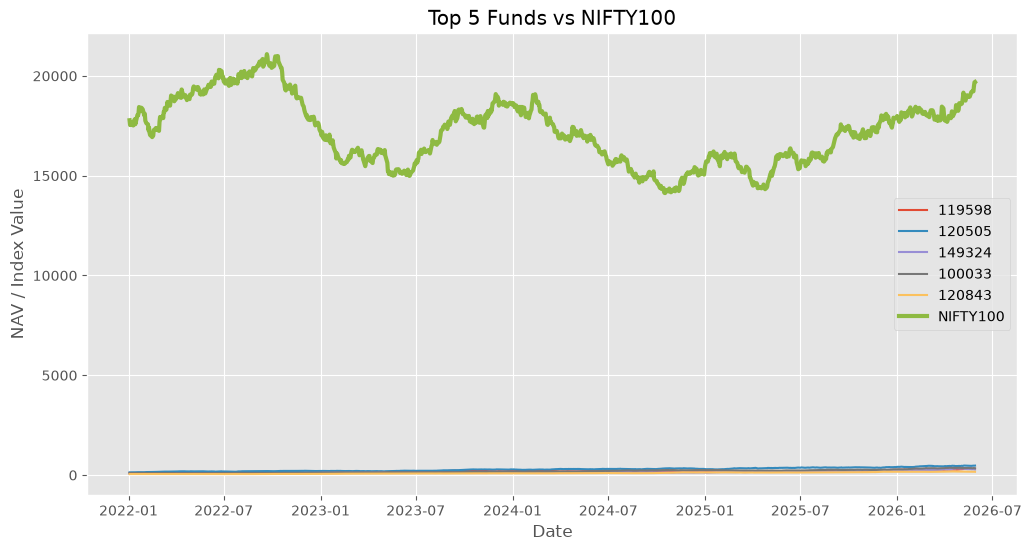

Benchmark Comparison Chart Saved Successfully!


In [21]:
# Benchmark Comparison Chart

import matplotlib.pyplot as plt

# Select Top 5 Funds based on Fund Score
top5_codes = scorecard.head(5)["amfi_code"].tolist()

plt.figure(figsize=(12,6))

# Plot Top 5 Funds
for code in top5_codes:

    fund = nav_history[nav_history["amfi_code"] == code]

    plt.plot(
        fund["date"],
        fund["nav"],
        label=str(code)
    )

# Plot NIFTY100
plt.plot(
    nifty100["date"],
    nifty100["close_value"],
    linewidth=3,
    label="NIFTY100"
)

plt.title("Top 5 Funds vs NIFTY100")
plt.xlabel("Date")
plt.ylabel("NAV / Index Value")
plt.legend()

plt.savefig(
    "charts/Benchmark_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Benchmark Comparison Chart Saved Successfully!")

In [22]:
# Prepare NIFTY50 and NIFTY100

benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty50 = benchmark[benchmark["index_name"] == "NIFTY50"].copy()
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

nifty50 = nifty50.sort_values("date")
nifty100 = nifty100.sort_values("date")

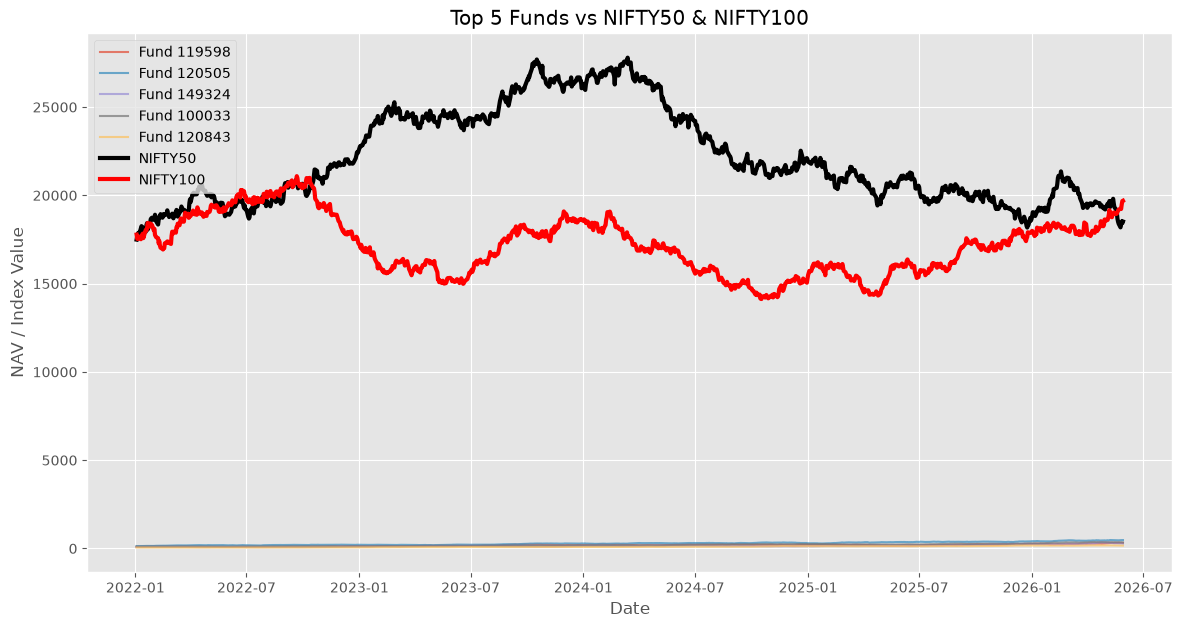

Benchmark Comparison Final Saved!


In [23]:
plt.figure(figsize=(14,7))

# Top 5 funds
for code in top5_codes:

    fund = nav_history[nav_history["amfi_code"] == code]

    plt.plot(
        fund["date"],
        fund["nav"],
        alpha=0.7,
        label=f"Fund {code}"
    )

# NIFTY50
plt.plot(
    nifty50["date"],
    nifty50["close_value"],
    color="black",
    linewidth=3,
    label="NIFTY50"
)

# NIFTY100
plt.plot(
    nifty100["date"],
    nifty100["close_value"],
    color="red",
    linewidth=3,
    label="NIFTY100"
)

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100")
plt.xlabel("Date")
plt.ylabel("NAV / Index Value")
plt.legend()

plt.savefig(
    "charts/Benchmark_Comparison_Final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Benchmark Comparison Final Saved!")

In [24]:
tracking_error = []

for code in top5_codes:

    fund = nav_history[
        nav_history["amfi_code"] == code
    ][["date","daily_return"]]

    merged_te = pd.merge(
        fund,
        nifty100[["date","benchmark_return"]],
        on="date"
    ).dropna()

    te = (
        (merged_te["daily_return"] -
         merged_te["benchmark_return"]).std()
    ) * np.sqrt(252)

    tracking_error.append([code, te])

tracking_error_df = pd.DataFrame(
    tracking_error,
    columns=["amfi_code","tracking_error"]
)

print(tracking_error_df)

tracking_error_df.to_csv(
    "tracking_error.csv",
    index=False
)

print("Tracking Error Saved Successfully!")

KeyError: "['benchmark_return'] not in index"

In [25]:
# Recalculate benchmark returns

benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

print(nifty100.head())

           date index_name  close_value  benchmark_return
1150 2022-01-03   NIFTY100     17778.24               NaN
1151 2022-01-04   NIFTY100     17537.52         -0.013540
1152 2022-01-05   NIFTY100     17607.73          0.004003
1153 2022-01-06   NIFTY100     17556.05         -0.002935
1154 2022-01-07   NIFTY100     17664.02          0.006150


In [26]:
print(nifty100.columns)

Index(['date', 'index_name', 'close_value', 'benchmark_return'], dtype='str')


In [27]:
# Recreate benchmark returns

benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

print(nifty100.columns)

Index(['date', 'index_name', 'close_value', 'benchmark_return'], dtype='str')


In [28]:
print(nifty100.columns)

Index(['date', 'index_name', 'close_value', 'benchmark_return'], dtype='str')


In [29]:
# Task 8 - Tracking Error

tracking_error = []

for code in top5_codes:

    # Fund returns
    fund = nav_history[
        nav_history["amfi_code"] == code
    ][["date", "daily_return"]]

    # Merge with benchmark
    temp = pd.merge(
        fund,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    # Remove missing values
    temp = temp.dropna()

    # Calculate Tracking Error
    te = (
        temp["daily_return"] - temp["benchmark_return"]
    ).std() * np.sqrt(252)

    tracking_error.append({
        "amfi_code": code,
        "tracking_error": te
    })

# Create DataFrame
tracking_error_df = pd.DataFrame(tracking_error)

# Add Scheme Name
tracking_error_df = tracking_error_df.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Save CSV
tracking_error_df.to_csv("tracking_error.csv", index=False)

print("✅ Tracking Error calculated successfully!")

tracking_error_df

✅ Tracking Error calculated successfully!


,amfi_code,tracking_error,scheme_name
0,119598,0.283881,SBI Small Cap Fund - Regular Plan - Growth
1,120505,0.231968,ICICI Pru Midcap Fund - Regular - Growth
2,149324,0.279170,DSP Small Cap Fund - Regular - Growth
3,100033,0.228699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
4,120843,0.206425,Kotak Flexicap Fund - Regular - Growth
